In [2]:
import time
import keras_cv
from tensorflow import keras
import matplotlib.pyplot as plt

Using TensorFlow backend


In [3]:
model = keras_cv.models.StableDiffusion(img_width=512, img_height=512)

By using this model checkpoint, you acknowledge that its usage is subject to the terms of the CreativeML Open RAIL-M license at https://raw.githubusercontent.com/CompVis/stable-diffusion/main/LICENSE


2026-09-20 05:10:54.499563: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-20 05:10:54.937510: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-20 05:10:54.937555: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-20 05:10:54.937560: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-09-20 05:10:54.939767: I external/lo

50/50 [==============================] - 78s 881ms/step


2026-09-20 05:12:26.492013: W external/local_xla/xla/service/gpu/conv_algorithm_picker.cc:808] None of the algorithms provided by cuDNN heuristics worked; trying fallback algorithms.
2026-09-20 05:12:26.492048: W external/local_xla/xla/service/gpu/conv_algorithm_picker.cc:811] Conv: (f32[1,512,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,512,64,64]{3,2,1,0}, f32[512,512,1,1]{3,2,1,0}, f32[512]{0}), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0}
2026-09-20 05:12:26.588585: W external/local_xla/xla/service/gpu/conv_algorithm_picker.cc:808] None of the algorithms provided by cuDNN heuristics worked; trying fallback algorithms.
2026-09-20 05:12:26.588800: W external/local_xla/xla/service/gpu/conv_algorithm_picker.cc:811] Conv: (f32[1,512,64,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,512,64,64]{3,2,1,0}, f32[512,512,1,1]{3,2,1,0}, f

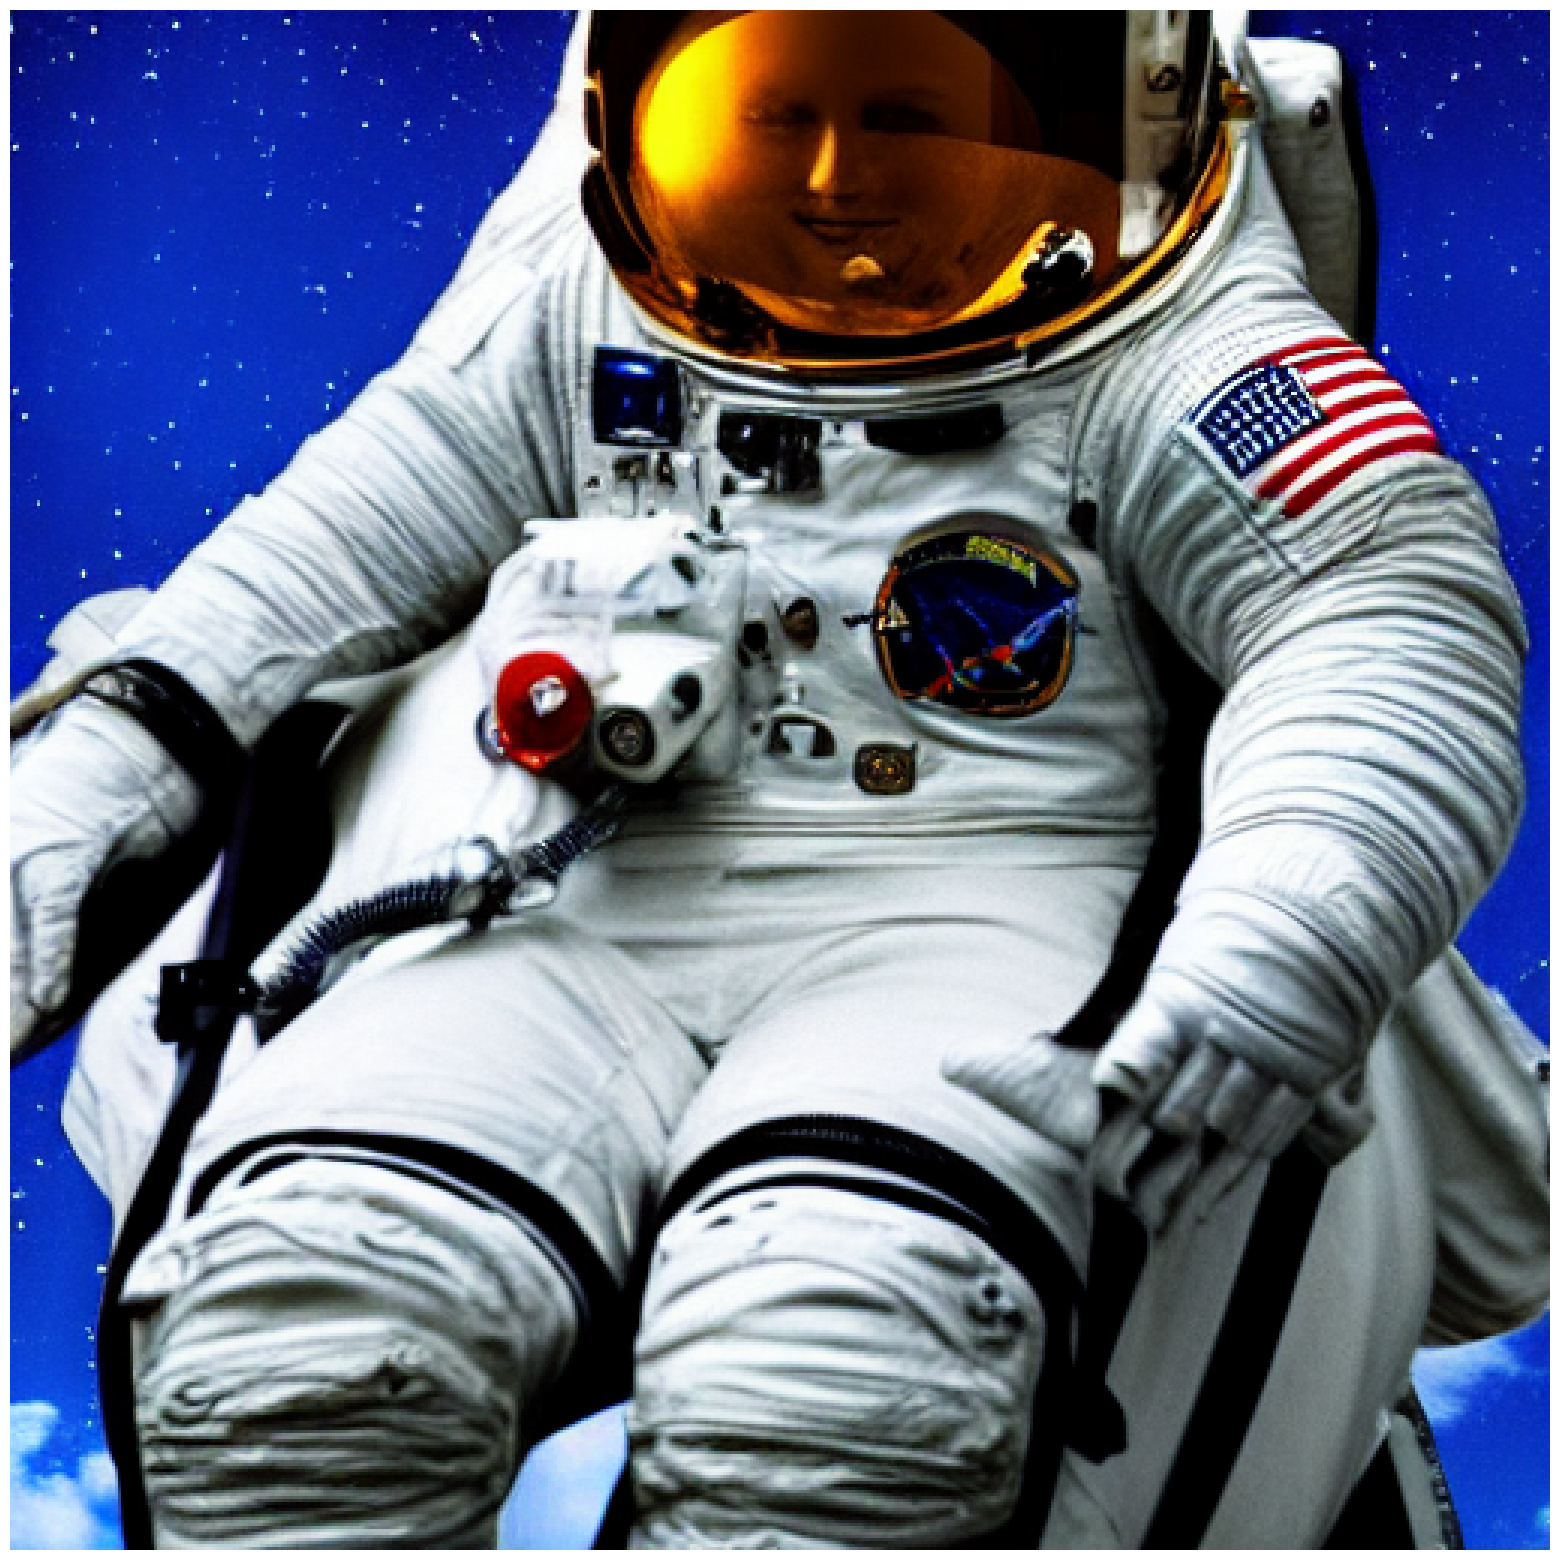

In [3]:
images = model.text_to_image("photograph of an astronaut riding a horse", batch_size=1)


def plot_images(images):
    plt.figure(figsize=(20, 20))
    for i in range(len(images)):
        ax = plt.subplot(1, len(images), i + 1)
        plt.imshow(images[i])
        plt.axis("off")


plot_images(images)

50/50 [==============================] - 44s 888ms/step


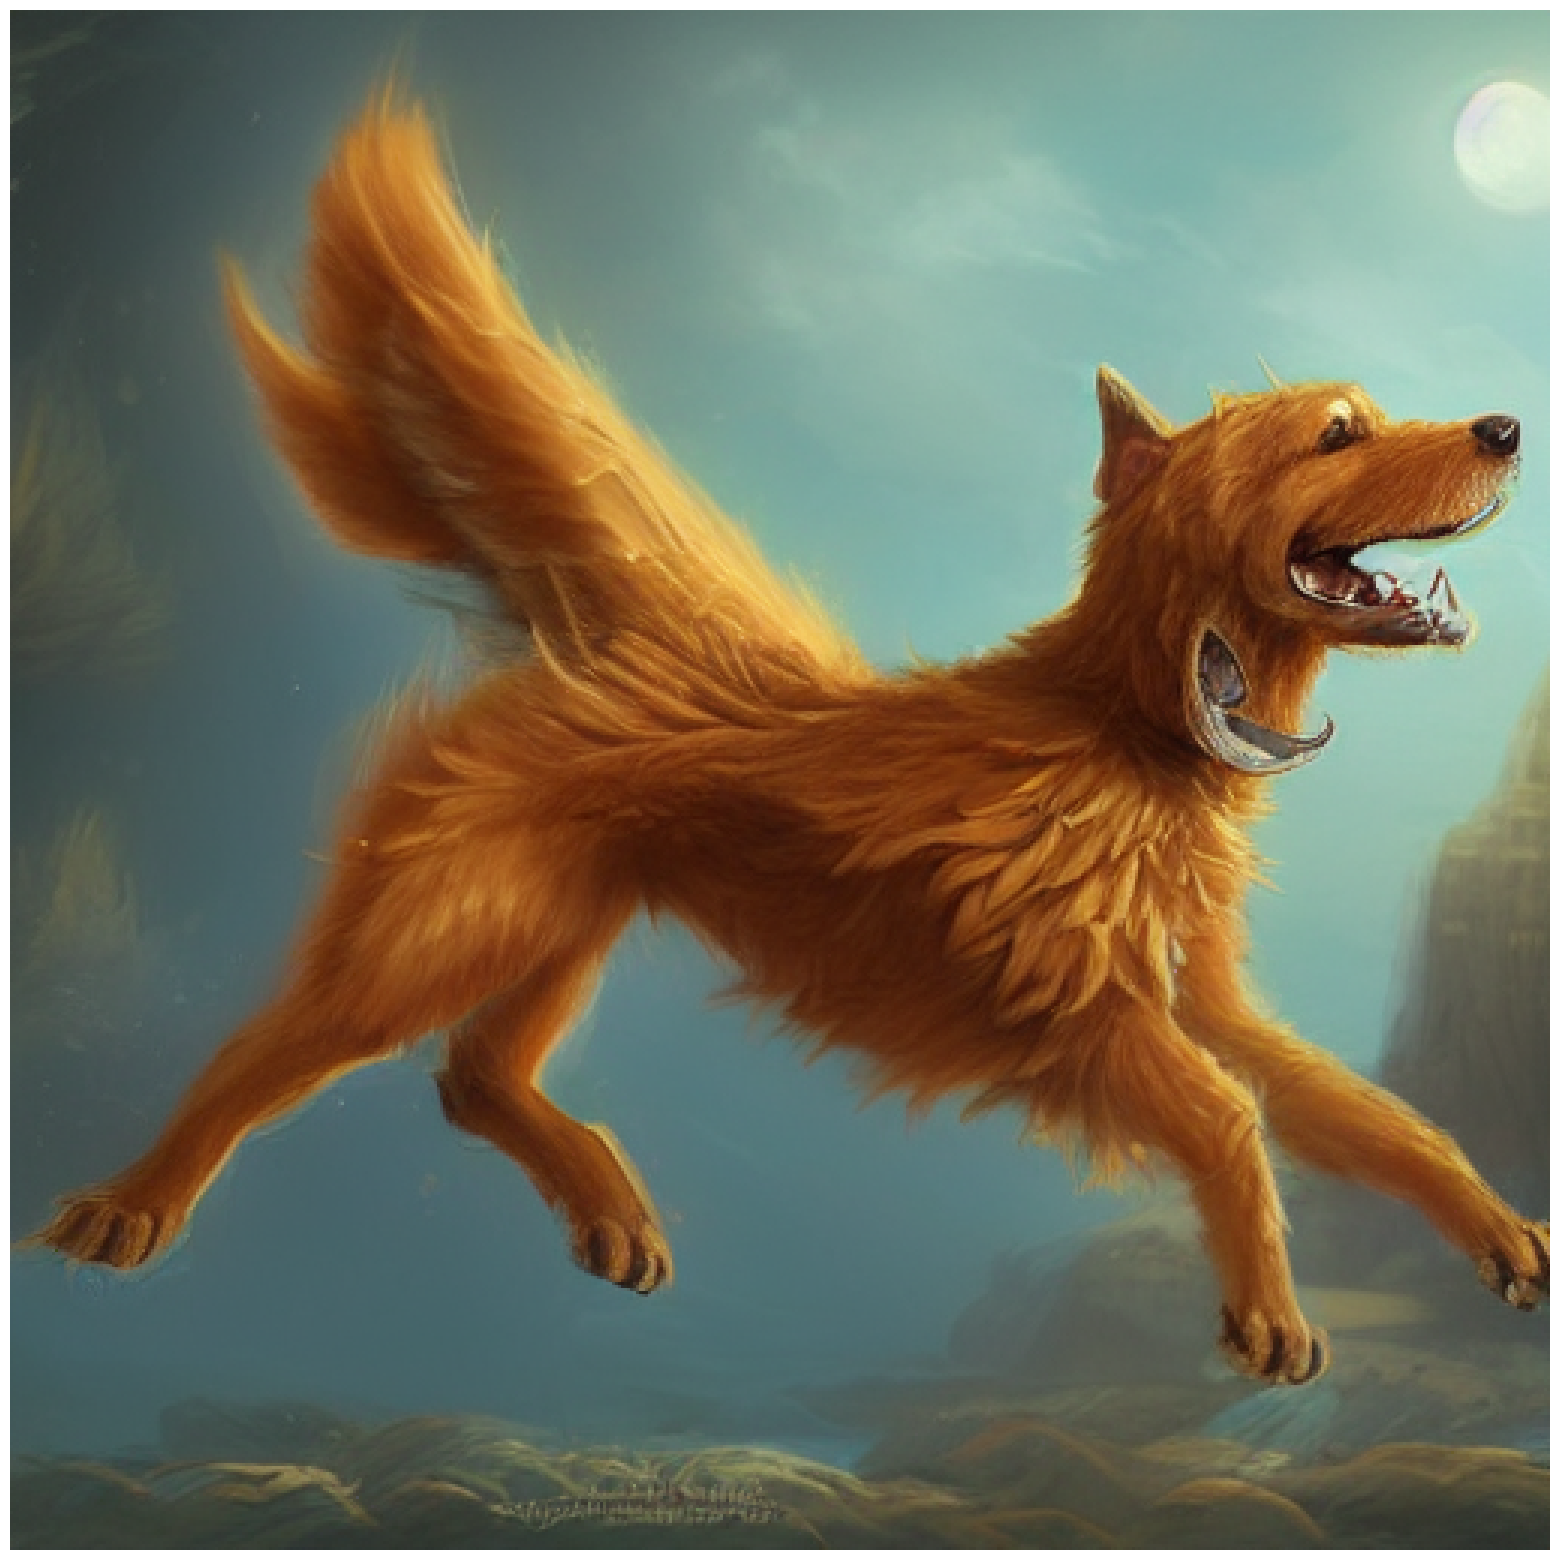

In [4]:
images = model.text_to_image(
    "cute magical flying dog, fantasy art, "
    "golden color, high quality, highly detailed, elegant, sharp focus, "
    "concept art, character concepts, digital painting, mystery, adventure",
    batch_size=1,
)
plot_images(images)

# Memory optimization

## 1. Enable Mixed Precision Training / Inference
By default, TensorFlow uses Float32 (32-bit precision). Switching your code to Float16 (16-bit precision) cuts your memory usage exactly in half with zero noticeable loss in image quality.Add these two lines at the very top of your script or notebook, right after importing TensorFlow:

In [1]:
import tensorflow as tf
from tensorflow.keras import mixed_precision

# Set global policy to float16
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

2026-09-20 05:25:14.120593: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-20 05:25:14.192263: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-20 05:25:14.192312: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-20 05:25:14.193310: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-20 05:25:14.200633: I tensorflow/core/platform/cpu_feature_guar

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 5050 Laptop GPU, compute capability 12.0


2026-09-20 05:25:17.192923: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-20 05:25:17.300228: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-20 05:25:17.300307: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-20 05:25:17.300318: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2348] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
2026-09-20 05:25:17.300850: I external/lo

## 2. Allow Memory GrowthBy default
TensorFlow tries to map and lock down almost all available VRAM at startup. If Windows or another app suddenly requests a bit of memory, TensorFlow crashes. Forcing memory growth tells TensorFlow to only allocate VRAM incrementally as needed.Add this right under your imports:

In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

## 3. If we use a higher batch_size like batch_size=3
Running a batch size of 3 means the model is trying to generate three separate high-resolution images completely simultaneously, which would overload the 8 GB of VRAM on your RTX 5050.

## Combined
Puting all the above performance tunings together

2026-09-20 05:46:31.611777: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f16[1,32,32,640]{3,2,1,0}, u8[0]{0}) custom-call(f16[1,32,32,640]{3,2,1,0}, f16[640,3,3,640]{3,2,1,0}, f16[640]{0}, f16[1,32,32,640]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":1,"leakyrelu_alpha":0} is taking a while...
2026-09-20 05:46:31.659884: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.048287179s
Trying algorithm eng0{} for conv (f16[1,32,32,640]{3,2,1,0}, u8[0]{0}) custom-call(f16[1,32,32,640]{3,2,1,0}, f16[640,3,3,640]{3,2,1,0}, f16[640]{0}, f16[1,32,32,640]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"conv_result_scale":1,"activation_mode":"kNone","side_input_

50/50 [==============================] - 118s 649ms/step


2026-09-20 05:47:40.223257: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng0{} for conv (f16[1,64,64,512]{3,2,1,0}, u8[0]{0}) custom-call(f16[1,64,64,512]{3,2,1,0}, f16[512,3,3,512]{3,2,1,0}, f16[512]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0} is taking a while...
2026-09-20 05:47:40.377833: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.154711497s
Trying algorithm eng0{} for conv (f16[1,64,64,512]{3,2,1,0}, u8[0]{0}) custom-call(f16[1,64,64,512]{3,2,1,0}, f16[512,3,3,512]{3,2,1,0}, f16[512]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0} is taking a while...
202

50/50 [==============================] - 34s 673ms/step


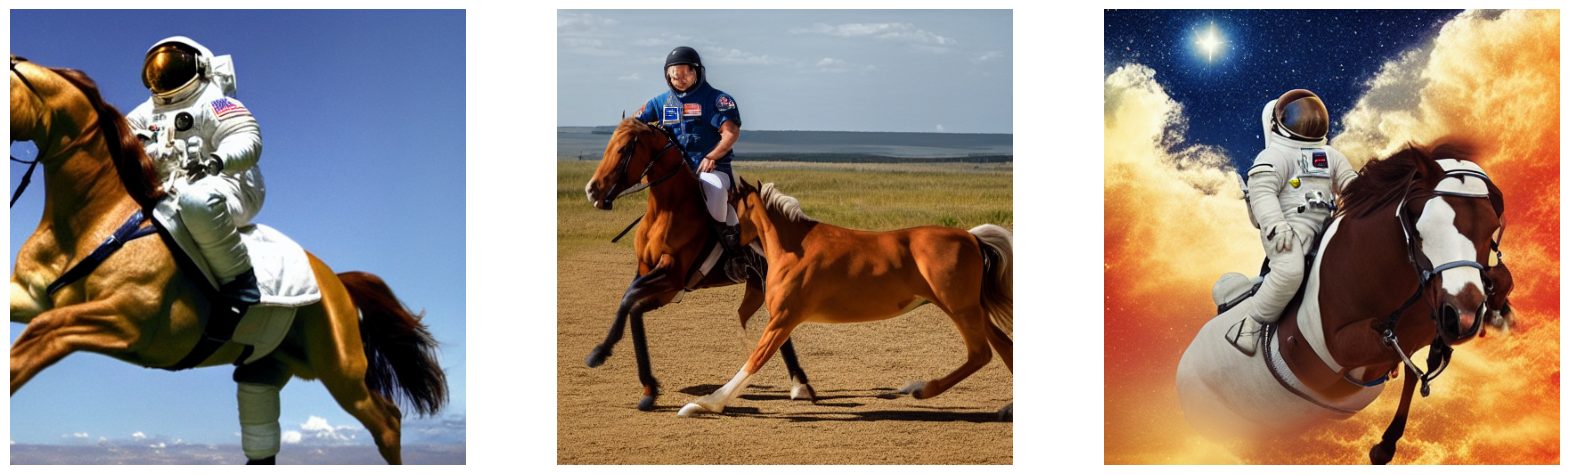

In [6]:
import matplotlib.pyplot as plt
import tensorflow as tf

# --- OPTIMIZATION PLUGINS ---
# 1. Enable memory growth so TensorFlow shares VRAM dynamically
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

# 2. Enable mixed precision to cut VRAM usage in half
tf.keras.mixed_precision.set_global_policy("mixed_float16")


# --- IMAGE GENERATION ---
# Generate 3 images sequentially (batch_size=1) instead of all at once
images = []
for _ in range(3):
    img = model.text_to_image(
        "photograph of an astronaut riding a horse", batch_size=1
    )
    images.extend(img)


# --- PLOTTING ---
def plot_images(images):
    plt.figure(figsize=(20, 20))
    for i in range(len(images)):
        ax = plt.subplot(1, len(images), i + 1)
        plt.imshow(images[i])
        plt.axis("off")


plot_images(images)
